In [1]:
# imports. NOTE! this should be run as a kaggle notebook,
# add the gwave dataset on the right sidebar
SEED = 123

import os
import numpy as np
np.random.seed(SEED)
import glob
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
import torch
from torch.utils.data import Dataset, DataLoader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cpu


In [2]:
# can view datset on ride sidebar, has many digits with .npy files underneath

# read the training labels in
labels = pd.read_csv("/kaggle/input/g2net-gravitational-wave-detection/training_labels.csv")

# read in the training data
ids = labels['id'].values # stores the id of each training data param
y = labels['target'].values # (num_labels,) 1 or 0 for if data contains a gwave

# read the official test labels in
test_labels = pd.read_csv("/kaggle/input/g2net-gravitational-wave-detection/sample_submission.csv")

test_ids = labels['id'].values
y_test = labels['target'].values



print (ids.shape); print (test_ids.shape)
print (y.shape)

(560000,)
(560000,)
(560000,)


In [3]:
# use the labels to get the directory of the datasets and read them in too
def id_to_path(sample_id, is_train=True):
    if is_train:
        return f"/kaggle/input/g2net-gravitational-wave-detection/train/{sample_id[0]}/{sample_id[1]}/{sample_id[2]}/{sample_id}.npy"
    else:
        return f"/kaggle/input/g2net-gravitational-wave-detection/test/{sample_id[0]}/{sample_id[1]}/{sample_id[2]}/{sample_id}.npy"

In [4]:
# test reading in the first path, so we know what the data looks like
path0 = id_to_path(sample_id=ids[0])
X0 = np.load(path0)
print (X0.shape)

(3, 4096)


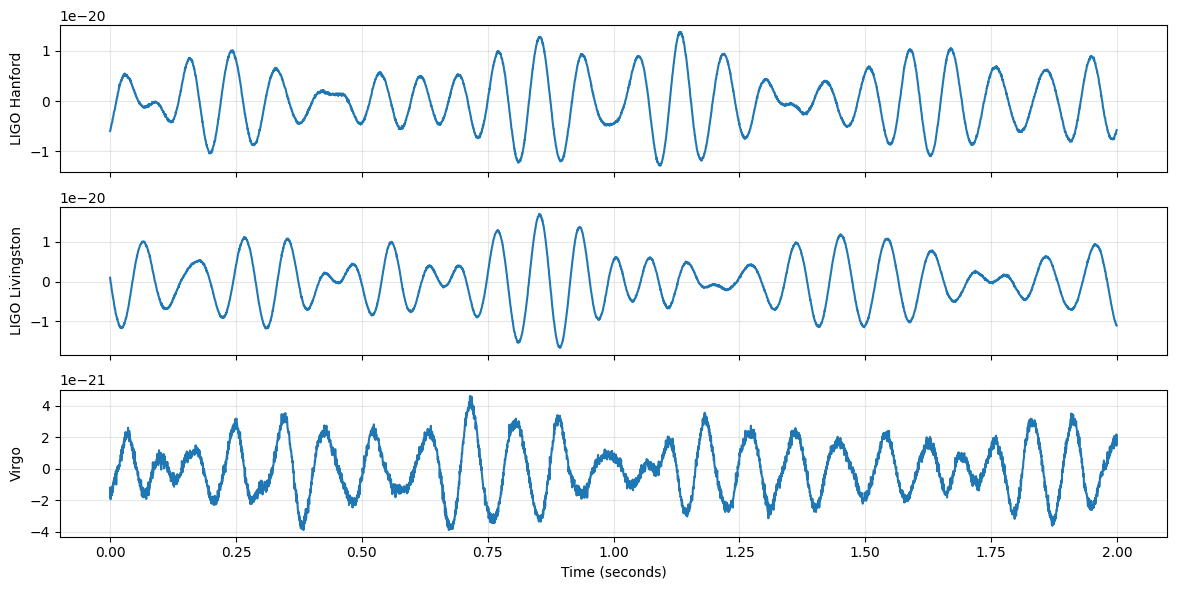

In [5]:
FS = 2048

def plot_g2net_sample(X, title=None):
    """
    X: numpy array of shape (3, 4096)
       X[0] = Hanford, X[1] = Livingston, X[2] = Virgo
    """
    assert X.shape[0] == 3, "Expected shape (3, N)"

    t = np.arange(X.shape[1]) / FS
    detectors = ["LIGO Hanford", "LIGO Livingston", "Virgo"]

    fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

    for i, ax in enumerate(axes):
        ax.plot(t, X[i])
        ax.set_ylabel(detectors[i])
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time (seconds)")

    if title:
        fig.suptitle(title, y=0.95)

    plt.tight_layout()
    plt.show()

plot_g2net_sample(X0)

In [6]:
# ok, i think it's too big to load into memory
# split train into train(0.7), test(0.15), split(0.15)
ids_tr, ids_temp, y_tr, y_temp = train_test_split(ids,
                                y,
                                test_size=0.3,
                                random_state=SEED,
                                stratify=y
                                )
ids_val, ids_te_hold, y_val, y_te_hold = train_test_split(ids_temp,
                                y_temp,
                                test_size=0.5,
                                random_state=SEED,
                                stratify=y_temp
                                )

In [7]:
class G2NetDataset(Dataset):
    def __init__(self, ids, targets, base_dir, train=True):
        """
        ids: array-like of strings (e.g. '00000e74ad')
        targets: array-like of 0/1 labels
        base_dir: '/kaggle/input/g2net-gravitational-wave-detection'
        """
        self.ids = ids
        self.targets = targets
        self.base_dir = base_dir
        self.train = train

    def __len__(self):
        return len(self.ids)

    def _id_to_path(self, sample_id):
        if self.train:
            return (
                f"{self.base_dir}/train/"
                f"{sample_id[0]}/{sample_id[1]}/{sample_id[2]}/"
                f"{sample_id}.npy"
            )
        else:
            return (
                f"{self.base_dir}/test/"
                f"{sample_id[0]}/{sample_id[1]}/{sample_id[2]}/"
                f"{sample_id}.npy"
            )

    def __getitem__(self, idx):
        sample_id = self.ids[idx]

        # load one waveform
        X = np.load(self._id_to_path(sample_id))

        # get label
        y = self.targets[idx]

        # convert to torch tensors
        X = torch.tensor(X, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        return X, y

In [8]:
BASE_DIR = "/kaggle/input/g2net-gravitational-wave-detection"

ds_tr = G2NetDataset(ids_tr, y_tr, BASE_DIR)
ds_val   = G2NetDataset(ids_val, y_val, BASE_DIR)
ds_te_hold  = G2NetDataset(ids_te_hold, y_te_hold, BASE_DIR)  # local holdout

ds_test = G2NetDataset(test_ids, y_test, BASE_DIR)

In [9]:
train_loader = DataLoader(
    ds_tr,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    ds_val,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_hold_loader = DataLoader(
    ds_te_hold,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# official test dataset
test_loader = DataLoader(
    ds_test,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader

X, y = next(iter(train_loader))

print("X:", X.shape)  # (32, 3, 4096)
print("y:", y.shape)  # (32,)
print("y values:", y[:5])

# for features, labels in train_loader:
#     print(features.shape, labels)

X: torch.Size([32, 3, 4096])
y: torch.Size([32])
y values: tensor([0., 0., 0., 1., 0.])
